In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_2d,net_2d,source_eval,error_general_2d,main
CUDA_LAUNCH_BLOCKING=1

def single_S(y,x_left,x_right,y_below,y_upper,center,r): # Single source
    cond=(y[:,0]-center[0])**2+(y[:,1]-center[1])**2<=r**2
    return 0.5*np.exp(-550*((y[:,0]-center[0])**2+(y[:,1]-center[1])**2))*cond

def ana_S(y,x_left,x_right,y_below,y_upper,center,r): # Total source
    cond1=(y[:,0]-center[0,0])**2+(y[:,1]-center[0,1])**2<=r**2
    cond2=(y[:,0]-center[1,0])**2+(y[:,1]-center[1,1])**2<=r**2
    return 0.5*np.exp(-550*((y[:,0]-center[0,0])**2+(y[:,1]-center[0,1])**2))*cond1+0.5*np.exp(-550*((y[:,0]-center[1,0])**2+(y[:,1]-center[1,1])**2))*cond2



cuda:1


In [3]:
import copy
Nx,Ny=1,1
Ix,Iy=4,4
nx,ny=3,3
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=-0.3,0.3,-0.3,0.3
b_x_min,b_x_max,b_y_min,b_y_max=-0.35,0.35,-0.35,0.35

num_batches_gauss=1
b_n=20
points_b=mea_2d.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n)

x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.06
center_true=np.array([[-0.06,0.0],[0.08,0.0]])
number_gene=50
eps=0.005
batch_number_rec_mea,mea=2,1
cupy_device = device.index if device.type == "cuda" else 0
S_int_true1, F_mea_b1, F_mea_db_x11, F_mea_db_x21 = generate_data.boundary_data_circle(kk, number_gene, points_b, single_S,[],[],[],[],center_true[0],r_true,eps,mea,batch_number_rec_mea,device,cupy_device)
S_int_true2, F_mea_b2, F_mea_db_x12, F_mea_db_x22 = generate_data.boundary_data_circle(kk, number_gene, points_b, single_S, [],[],[],[],center_true[1], r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
F_mea_b0 = F_mea_b1 + F_mea_b2
F_mea_db_x10 = F_mea_db_x11 + F_mea_db_x12
F_mea_db_x20= F_mea_db_x21 + F_mea_db_x22
F=inverse_solver.F(F_mea_b0,F_mea_db_x10,F_mea_db_x20)

cells= mesh.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b)
initial_cells=copy.deepcopy(cells)
R_m=20
r_low,r_upper=0.18,0.2
b_below,b_upper=-0.51,-0.49


In [4]:
M=2400
af="Tanh"   # Initial activation setting
R_m=5
cupy_device = device.index if device.type == "cuda" else 0
models0 = net_2d.pre_define(Nx,Ny,M,R_m,"Tanh",tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],device)


In [9]:
models0=torch.load("./Noise/noise=0.5%/models0_33_2400_2763_1e-05.pth")

/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


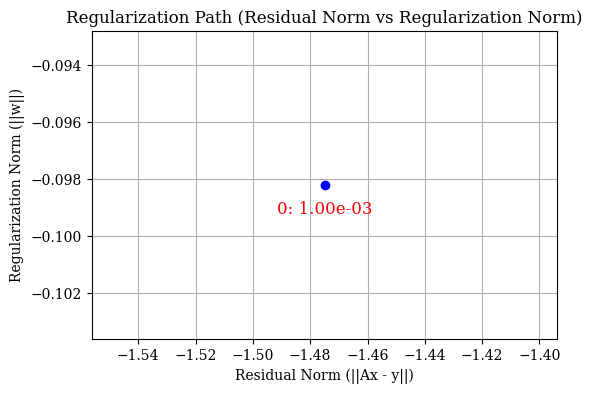

第 0 次迭代的train误差：
第 0 次迭代的泛化误差：


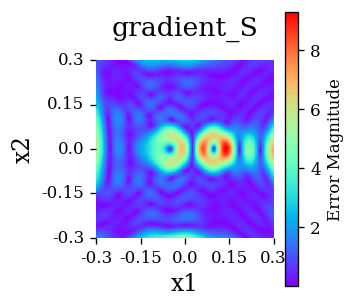

S_l_inf= 3.6886081526339947 S_L_2= 0.03206707327507239 S_l_2= 0.5158747730911538


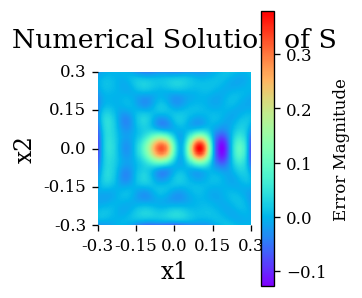

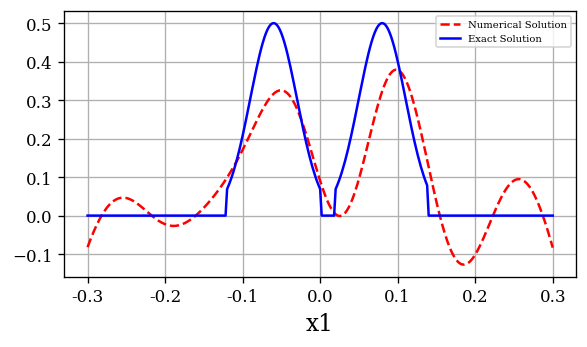

第 0 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


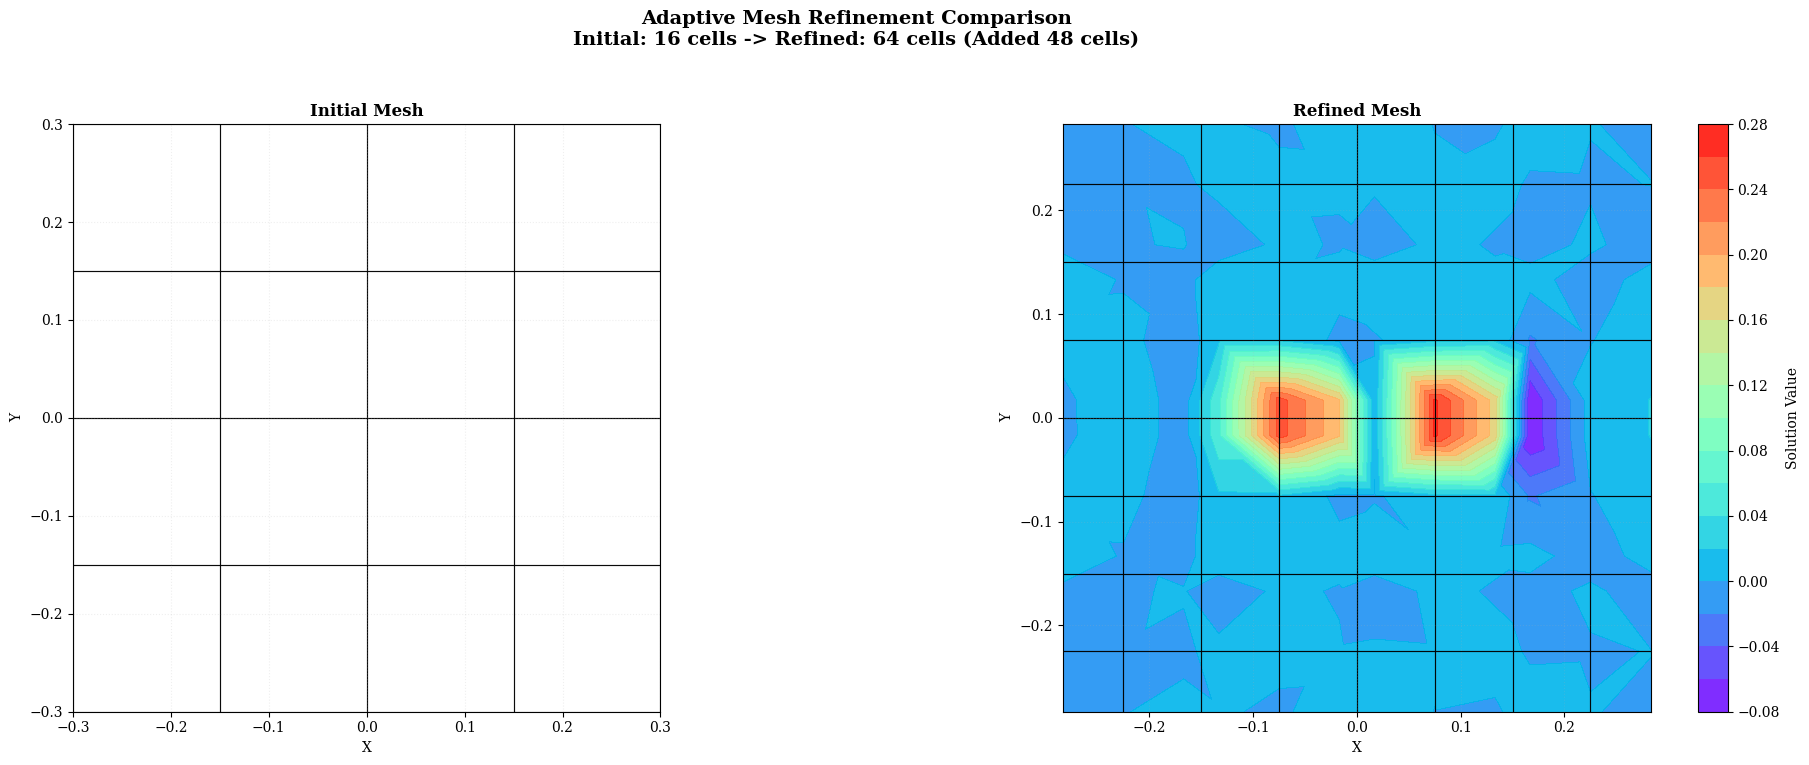

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


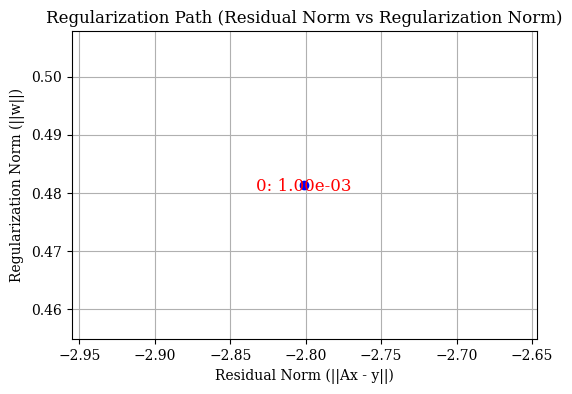

第 1 次迭代的train误差：
第 1 次迭代的泛化误差：


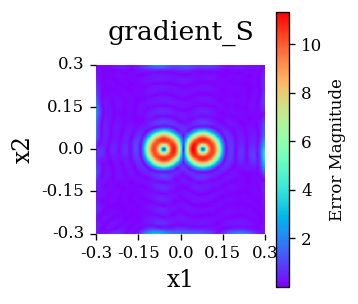

S_l_inf= 0.8912108320951455 S_L_2= 0.0063584922541918935 S_l_2= 0.1022913978053302


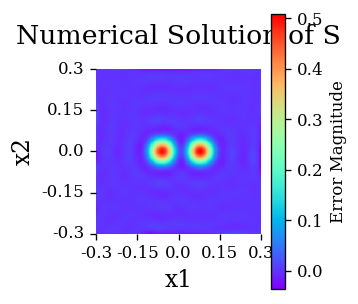

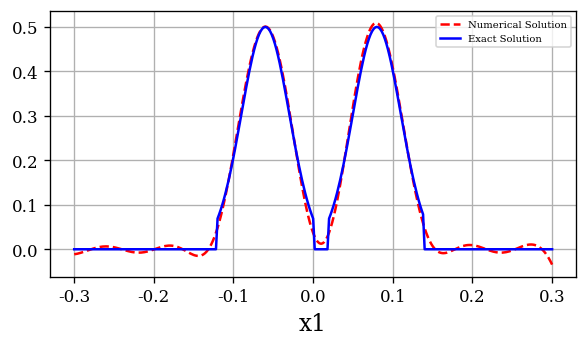

第 1 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


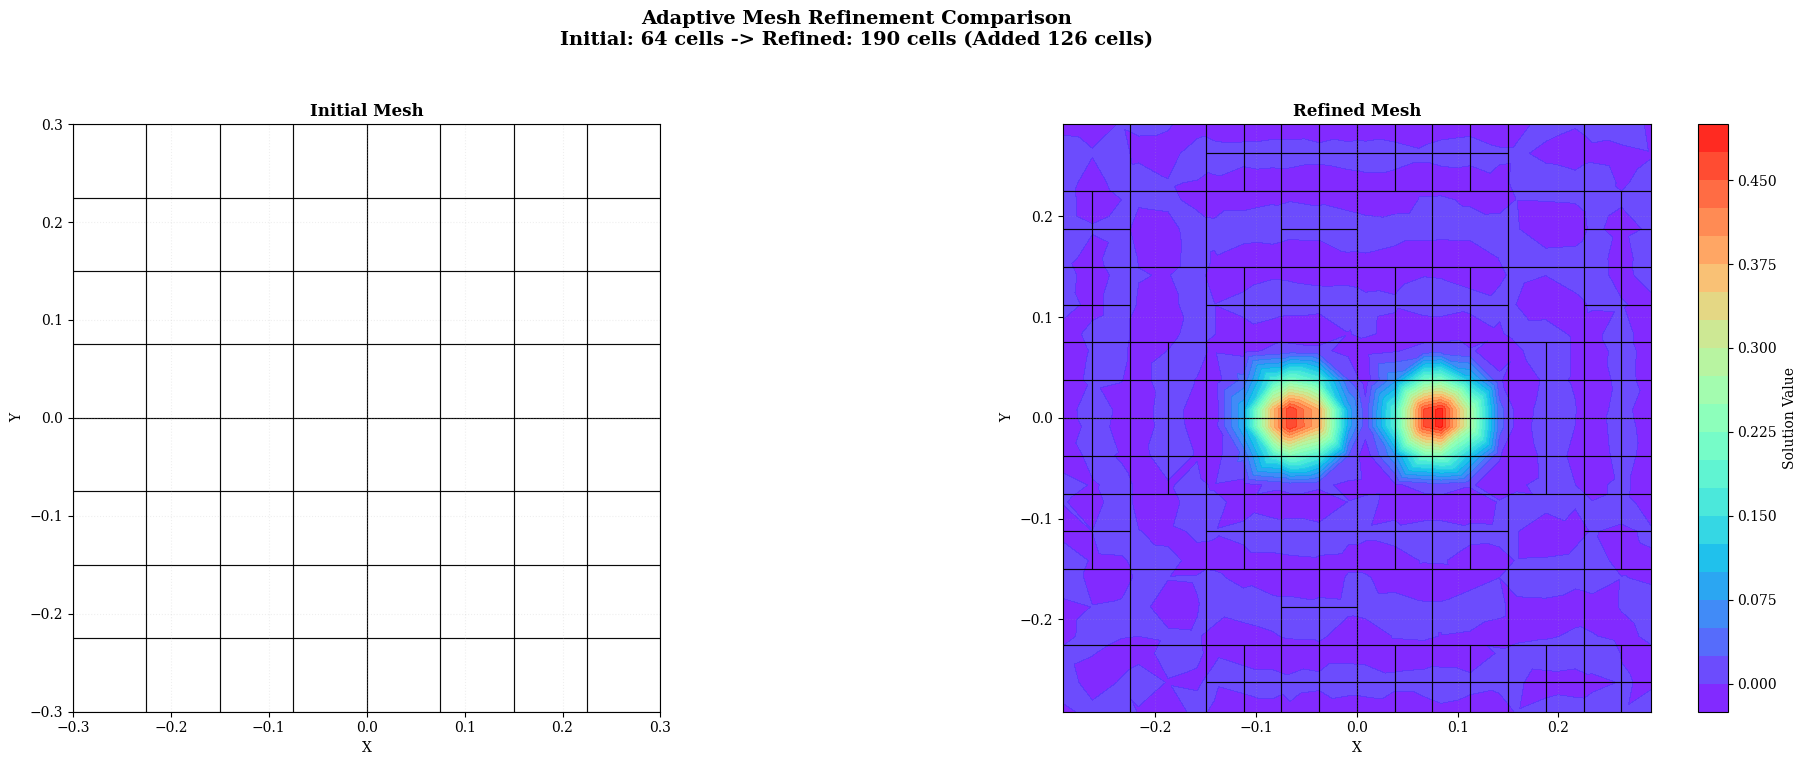

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


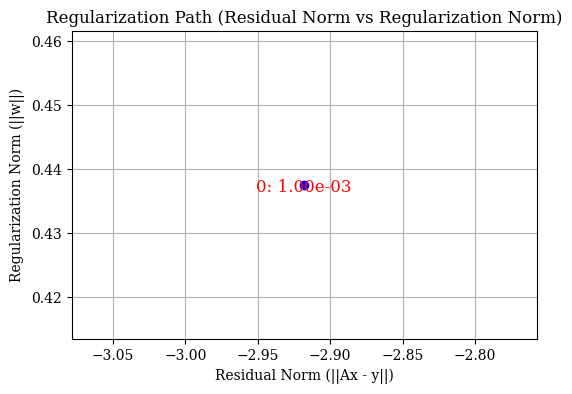

第 2 次迭代的train误差：
第 2 次迭代的泛化误差：


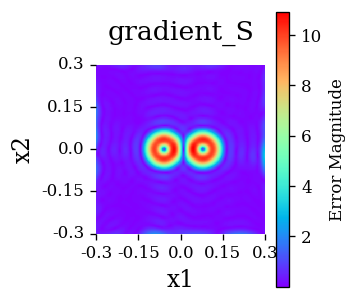

S_l_inf= 0.8979413987727428 S_L_2= 0.005972801388307533 S_l_2= 0.09608664733700183


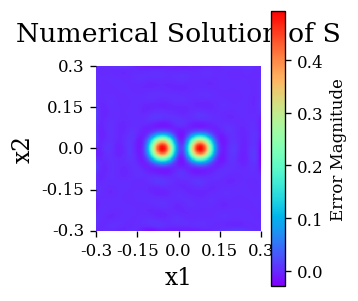

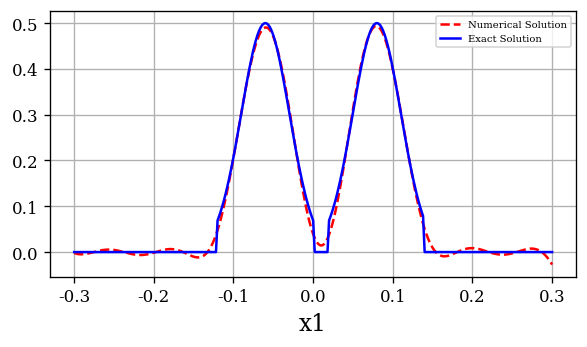

第 2 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


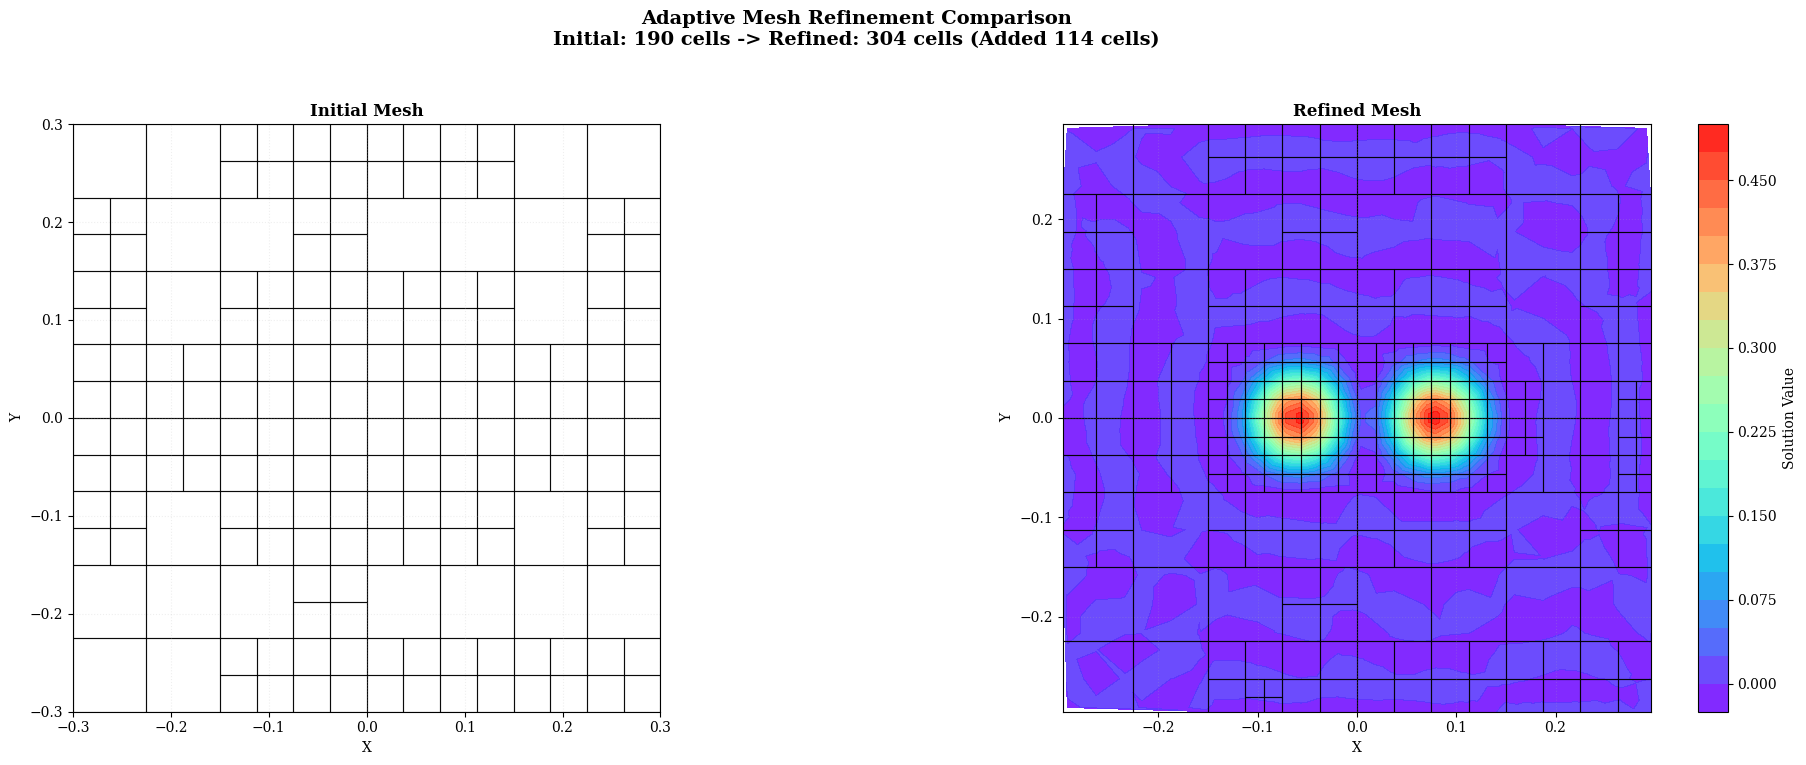

All visualizations completed!


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


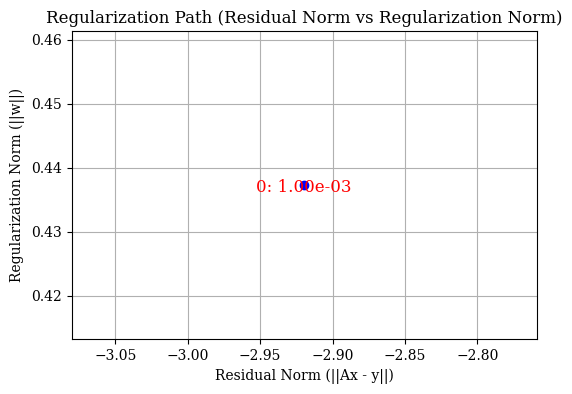

第 3 次迭代的train误差：
第 3 次迭代的泛化误差：


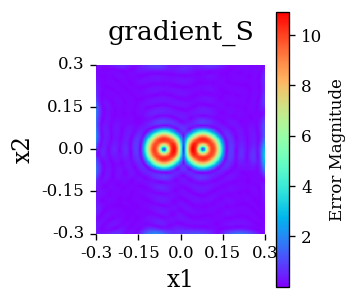

S_l_inf= 0.8978848724364958 S_L_2= 0.005973996685755804 S_l_2= 0.0961058765256033


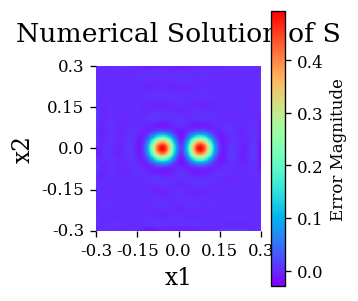

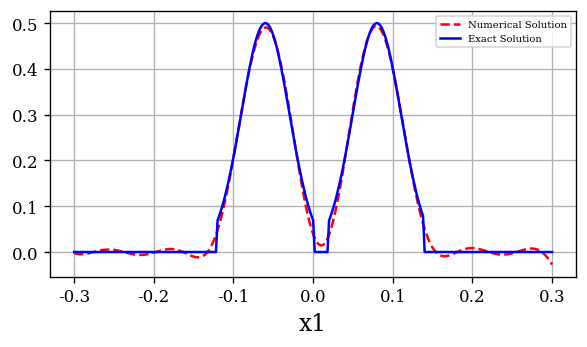

在第 3 次迭代结束


In [10]:
from importlib import reload
reload(error_general_2d)
reload(main)
iter_int= 5
Ix,Iy=4,4  # Number of grid cells in the x direction
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-3,-1,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="Tanh"
refine_threshold_S=1/100
refine_threshold_grad=1/300
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_l2,S_num_store=main.ada_int(iter_int,delta,cells,nx,models0,M,af,kk,F,tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_low,r_upper,center_true,r_true,ana_S,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,current_maxiter,max_level)


Number of detected clusters: 2
  CV of S_num: 0.738
Cluster 0: AR=1.02
  Res_Rect=0.078348 vs Res_Ellip=0.068808
  center=(-0.0606, 0.0001)
  -> Decision: Circle (Exp)
  CV of S_num: 0.735
Cluster 1: AR=1.02
  Res_Rect=0.078018 vs Res_Ellip=0.064103
  center=(0.0806, -0.0001)
  -> Decision: Circle (Exp)


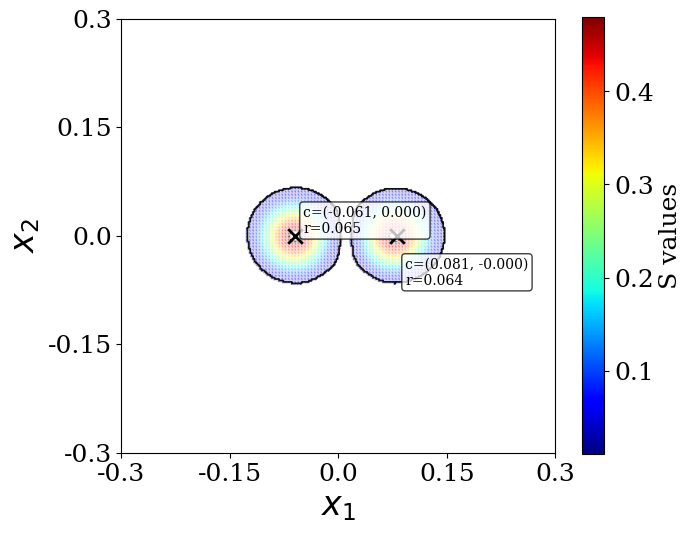

In [23]:
from importlib import reload
import bound_detect
reload(bound_detect)
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=5.0
mini_samples=20
para_abs=100
para_grad=3
results=bound_detect.detect_shape(g_S,X.T,Y.T,tau_x_min,tau_x_max,tau_y_min,tau_y_max,para_abs,para_grad,eps_cluster,mini_samples,S_num_store[-1],output_directory="./Noise/noise=0.5%", output_filename="plot.png", eps_mode="grid_scaled")

In [24]:
results

[{'cluster_id': 0,
  'shape': 'Circle',
  'params': {'center': array([-0.06055132,  0.00012493]),
   'radius': np.float64(0.06472828989890937)},
  'profile': 'Exp',
  'boundary_points': array([[-0.063984, -0.065736],
         [-0.063984, -0.065404],
         [-0.063984, -0.065072],
         ...,
         [-0.062988, -0.065736],
         [-0.06332 , -0.065736],
         [-0.063652, -0.065736]])},
 {'cluster_id': 1,
  'shape': 'Circle',
  'params': {'center': array([ 8.05569022e-02, -7.80372450e-05]),
   'radius': np.float64(0.06440182426930954)},
  'profile': 'Exp',
  'boundary_points': array([[ 0.07805, -0.06568],
         [ 0.07805, -0.06535],
         [ 0.07805, -0.06502],
         ...,
         [ 0.07904, -0.06568],
         [ 0.07871, -0.06568],
         [ 0.07838, -0.06568]])}]

In [25]:
center1=results[0]['params']['center']
r1=results[0]['params']['radius']
center2=results[1]['params']['center']
r2=results[1]['params']['radius']

In [26]:
# k=1 r=0.2 R_m=0.3 K=1000 M=800*2
M0=2400
M1=2000
M2=2000
R_m=1 #w -0.6~0.6 b: -0.3-0.3
rangee1=[np.abs(center1[0])*0.05,np.abs(center1[1])*2]
rangee2=[np.abs(center2[0])*0.05,np.abs(center2[1])*2]
r_minl,r_maxl=r1*(1-0.1),r1*(1+0.03)
r_minr,r_maxr=r2*(1-0.1),r2*(1+0.03)
b1_minl,b1_maxl=-(center1[0]*(1-0.03)),-(center1[0]*(1+0.03))
b2_minl,b2_maxl=-(center1[1]*(1+0.03)),(center1[1]*(1+0.03))
b1_minr,b1_maxr=-(center2[0]*(1+0.03)),-(center2[0]*(1-0.03))
b2_minr,b2_maxr=(center2[1]*(1+0.03)),-(center2[1]*(1+0.03))
v_min,v_max=-1000,0
peak_min,peak_max=0.3,0.6
K_min,K_max=1000,20000
#models0 = net_2d.pre_define(Nx,Ny,M0,1,"Tanh",tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_min,r_max,b1_min1,b1_max1,b2_min1,b2_max1,peak_min,peak_max,v_min,v_max,K_min,K_max,device)
models1 = net_2d.pre_define(Nx,Ny,M1,1,"Gauss",tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_minl,r_maxl,b1_minl,b1_maxl,b2_minl,b2_maxl,peak_min,peak_max,v_min,v_max,K_min,K_max,device)
models2 = net_2d.pre_define(Nx,Ny,M2,1,"Gauss",tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_minr,r_maxr,b1_minr,b1_maxr,b2_minr,b2_maxr,peak_min,peak_max,v_min,v_max,K_min,K_max,device)
af="mix"
sum_mat,all_g_p1,all_g_n,cells_copy1=matrix_assemble.mat_assemble2(cells_store[-1],models0,models1,models2,"mix",kk,0,points_b,device,cupy_device)


/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


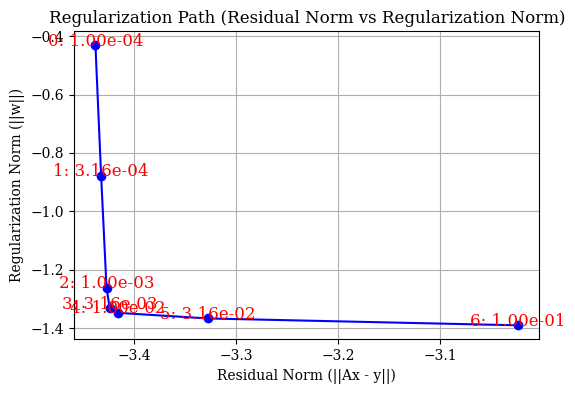

In [27]:
lamb_regu=np.logspace(-4,-1,7,endpoint=True)
res,reg_norm,w_store=inverse_solver.L_curve(M0,M1,M2,af,sum_mat,F,lamb_regu,cupy_device) # Solve first

lamb: 1e-05
S_l_inf= 0.7341792371066744 S_L_2= 0.0025889074211420584 S_l_2= 0.04164870354644639


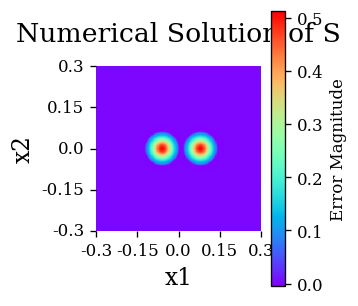

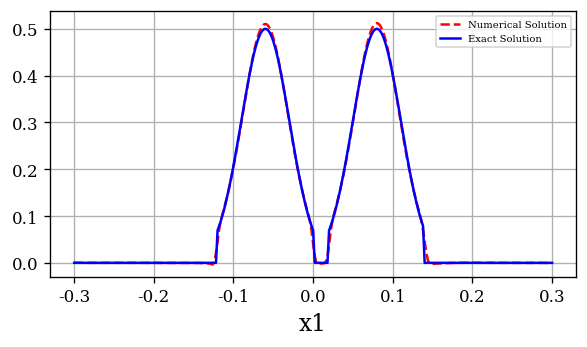

In [29]:
lamb=lamb_regu[3]**2
print('lamb:', lamb)
S_test_num,S_test_true,S_l_inf1,S_l_21,g_SS=error_general_2d.test(models0,models1,models2,150,150,w_store[:,3],"mix",True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],center_true,r_true,ana_S,0,device)


In [30]:
# Save the models1 model
torch.save(models0,f"./Noise/noise=0.5%/models0_33_2400_{point_number[-1]}_{lamb}.pth")
torch.save(models1,f"./Noise/noise=0.5%/models1_33_2000_left.pth")
torch.save(models2,f"./Noise/noise=0.5%/models2_33_2000_right.pth")

In [31]:
np.save(f"./Noise/noise=0.5%/S_num_{lamb}",S_test_num)
np.save("./Noise/noise=0.5%/all_mat",sum_mat)
np.save("./Noise/noise=0.5%/w_store",w_store)
np.save("./Noise/noise=0.5%/F_mea_b",F_mea_b0)
np.save("./Noise/noise=0.5%/F_mea_db_x1",F_mea_db_x10)
np.save("./Noise/noise=0.5%/F_mea_db_x2",F_mea_db_x20)
np.save("./Noise/noise=0.5%/F",F)

In [32]:
n_integral=len(cells_store[-1])*9
print('n_integral:',n_integral)
print('center1[0]:',center1)
print('center2[1]:',center2)
print('r1:',r1)
print('r2:',r2)
print('S_l2[-1]:',S_l2[-1])
print('lamb_regu:',lamb)
print('S_l21:',S_l_21)

n_integral: 2736
center1[0]: [-0.06055132  0.00012493]
center2[1]: [ 8.05569022e-02 -7.80372450e-05]
r1: 0.06472828989890937
r2: 0.06440182426930954
S_l2[-1]: 0.0961058765256033
lamb_regu: 1e-05
S_l21: 0.04164870354644639
